In [1]:
# sobel filter for detecting verticle and horizontal edges,/
# also do so usimg canny filter /
# explore and use laplacian filter, /
# explore and use haris corner detector/
# explore and use sift/
# apply various filter bank to detect texture in the image/
# assuming that your task is to classify image in 3 classes (dog, cat, horse etc) extract feature from the image using various feature extraction process/

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

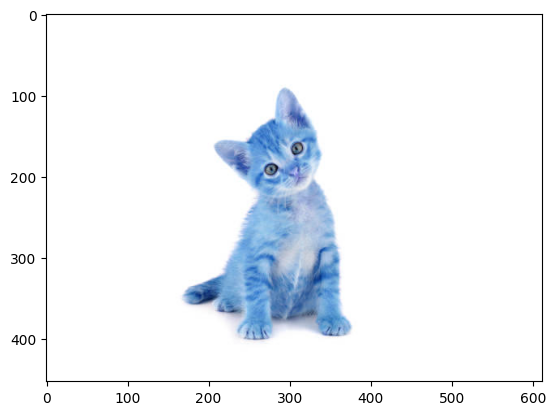

In [43]:
img = cv2.imread('cat.jpg')
plt.imshow(img)
plt.show()

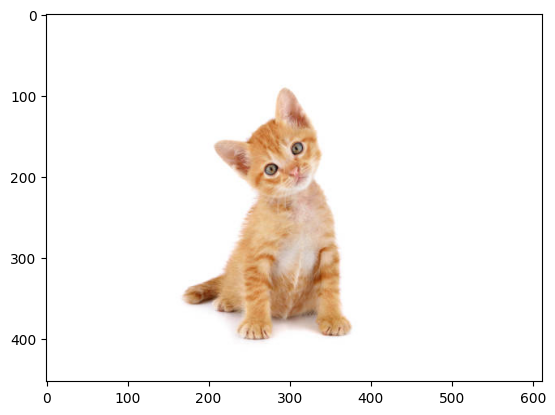

In [44]:
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [45]:
img.shape

(453, 612, 3)

In [46]:
sobel_x = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)  # Gradient in x direction
sobel_y = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3) # gradient in x direction

In [47]:
print(type(sobel_x))
print(sobel_x.shape)
print(sobel_x.max())
print(sobel_y.min())

<class 'numpy.ndarray'>
(453, 612, 3)
659.0
-584.0


In [48]:
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

In [49]:
print(type(sobel_mag))
print(sobel_mag.shape)
print(sobel_mag.max())
print(sobel_mag.min())

<class 'numpy.ndarray'>
(453, 612, 3)
931.9667376038697
0.0


In [50]:
# Normalize Sobel outputs to 0-255 for display
sobel_x = cv2.normalize(np.abs(sobel_x), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
sobel_y = cv2.normalize(np.abs(sobel_y), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
sobel_mag = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

In [51]:
print(type(sobel_mag))
print(sobel_mag.shape)
print(sobel_mag.max())
print(sobel_mag.min())

<class 'numpy.ndarray'>
(453, 612, 3)
254
0


In [52]:
print(type(sobel_x))
print(sobel_x.shape)
print(sobel_x.max())
print(sobel_x.min())

<class 'numpy.ndarray'>
(453, 612, 3)
255
0


In [53]:
print(type(sobel_y))
print(sobel_y.shape)
print(sobel_y.max())
print(sobel_y.min())

<class 'numpy.ndarray'>
(453, 612, 3)
255
0


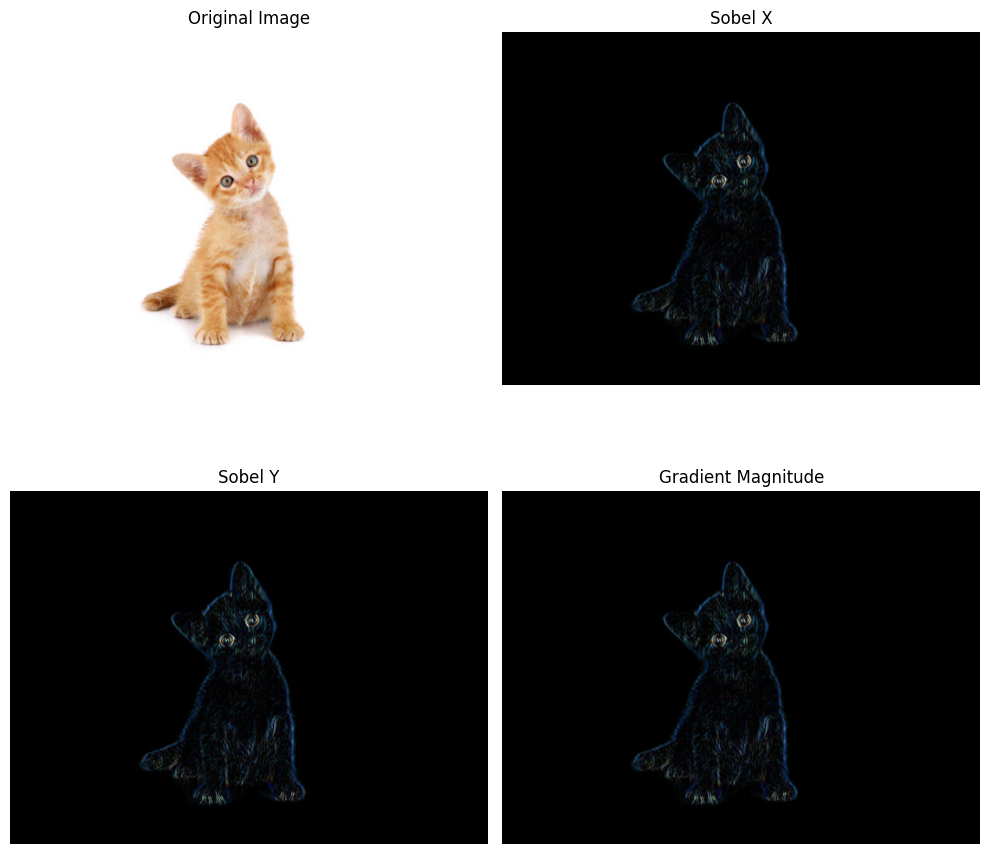

In [54]:

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("Sobel X")
plt.imshow(sobel_x, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("Sobel Y")
plt.imshow(sobel_y, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Gradient Magnitude")
plt.imshow(sobel_mag, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

(-0.5, 611.5, 452.5, -0.5)

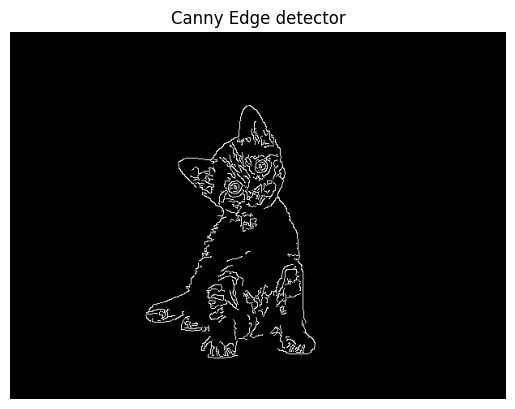

In [55]:
lowt = 100
hight = 200
img_canny = cv2.Canny(img,lowt,hight)
plt.title("Canny Edge detector")
plt.imshow(img_canny,cmap='gray')
plt.axis('off')

(-0.5, 611.5, 452.5, -0.5)

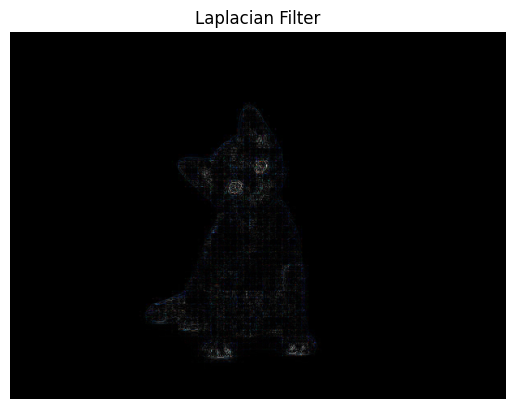

In [66]:
# Laplacian Filter
laplacian_kernel = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
])

laplacian_edges = cv2.Laplacian(img, cv2.CV_64F)  # Use CV_64F to handle negative gradients
laplacian_edges = np.uint8(np.absolute(laplacian_edges))

plt.title("Laplacian Filter")
plt.imshow(custom_laplacian_edges,cmap='gray')
plt.axis('off')


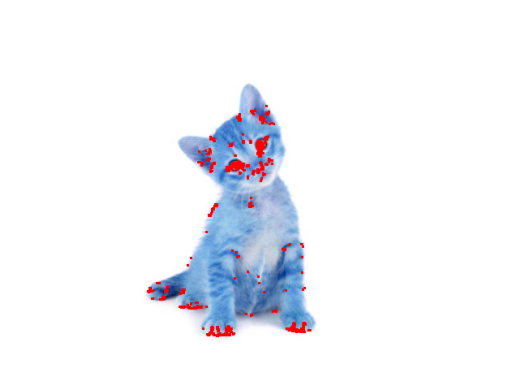

In [67]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)
dst = cv2.cornerHarris(gray, 2, 3, 0.04)
dst = cv2.dilate(dst, None)
img[dst > 0.01 * dst.max()] = [0, 0, 255]
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

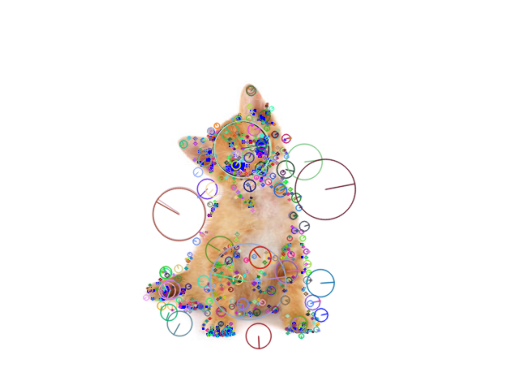

In [70]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(img_rgb, None)
img_rgb = cv2.drawKeypoints(img_rgb, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()



In [72]:
img = cv2.imread('cat.jpg')

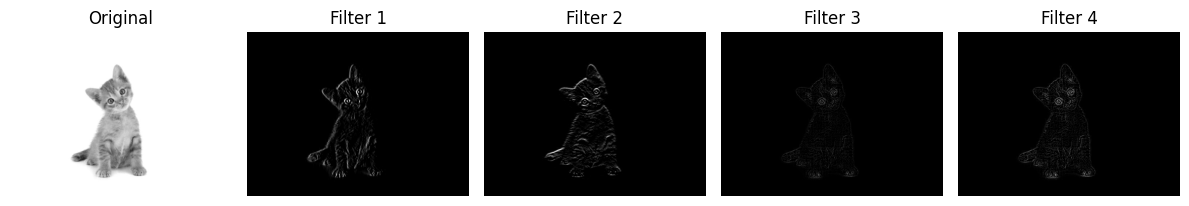

In [73]:
filters = [
    np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]]),  # Sobel-X
    np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]]),  # Sobel-Y
    np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]]), # Laplacian
    np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]) # High-pass
]

# Convert the image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Apply each filter in the filter bank
filtered_images = [cv2.filter2D(gray_img, -1, f) for f in filters]

# Plot the original image and filtered textures
plt.figure(figsize=(12, 6))
plt.subplot(1, len(filtered_images) + 1, 1)
plt.imshow(gray_img, cmap='gray')
plt.title('Original')
plt.axis('off')

for i, filtered_img in enumerate(filtered_images):
    plt.subplot(1, len(filtered_images) + 1, i + 2)
    plt.imshow(filtered_img, cmap='gray')
    plt.title(f'Filter {i + 1}')
    plt.axis('off')

plt.tight_layout()
plt.show()